# IND320 — Project Work, Part 1: Dashboard Basics

**GitHub repository:** https://github.com/<your-username>/<your-repo-name>
**Streamlit app:** https://<your-app-name>.streamlit.app/

## AI usage
Briefly describe here which AI tools you used (e.g. Claude, ChatGPT, GitHub Copilot),
for what (e.g. debugging, boilerplate code, this notebook's structure), and how you
verified the output before using it.

*(Fill in your own 2-4 sentence description.)*


## Log (300-500 words)

Describe the compulsory work for this hand-in here: what you did in the Jupyter
Notebook, what you built in the Streamlit app, any issues you ran into and how you
solved them, and what you learned.

*(Fill in your own 300-500 word log before submitting — this is a placeholder.)*


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


## 2. Load the data

`reservoirs.csv` is NVE's weekly reservoir-fill export. The raw export mixes
several region breakdowns in one file (price areas EL 1-5, watercourse
regions VASS 1-3, and a nationwide total NO); this copy has already been
filtered down to the nationwide total (`omrType == "NO"`) so each row is one
week for the whole country. We rename the original Norwegian headers to
clear English names here.


In [2]:
# Load the raw CSV
df = pd.read_csv("reservoirs.csv", parse_dates=["dato_Id"])

# Rename headers to English / understandable names
rename_map = {
    "dato_Id": "Date",
    "fyllingsgrad": "Fill_degree",                  # fraction of capacity, 0-1
    "kapasitet_TWh": "Capacity_TWh",                 # total reservoir capacity, TWh
    "fylling_TWh": "Fill_TWh",                       # energy currently stored, TWh
    "fyllingsgrad_forrige_uke": "Fill_degree_prev_week",
    "endring_fyllingsgrad": "Fill_degree_change",    # week-over-week change in fill degree
}
df = df.rename(columns=rename_map)
df = df.set_index("Date").sort_index()
df.head()


,Fill_degree,Capacity_TWh,Fill_TWh,Fill_degree_prev_week,Fill_degree_change
Date,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


## 3. Print the contents in a relevant way

In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print()
print(df.describe())


Shape: 1653 rows x 5 columns
Date range: 1995-01-08 to 2026-09-06

       Fill_degree  Capacity_TWh     Fill_TWh  Fill_degree_prev_week  \
count  1653.000000    1653.00000  1653.000000            1653.000000   
mean      0.622086      87.43758    54.393716               0.622156   
std       0.195967       0.00000    17.134922               0.195992   
min       0.180250      87.43758    15.760602               0.180260   
25%       0.460607      87.43758    40.274364               0.460607   
50%       0.645902      87.43758    56.476093               0.647445   
75%       0.789274      87.43758    69.012170               0.789271   
max       0.966916      87.43758    84.544820               0.966892   

       Fill_degree_change  
count         1653.000000  
mean            -0.000070  
std              0.027704  
min             -0.144430  
25%             -0.022063  
50%             -0.005650  
75%              0.016337  
max              0.125069  


## 4. Plot each column separately

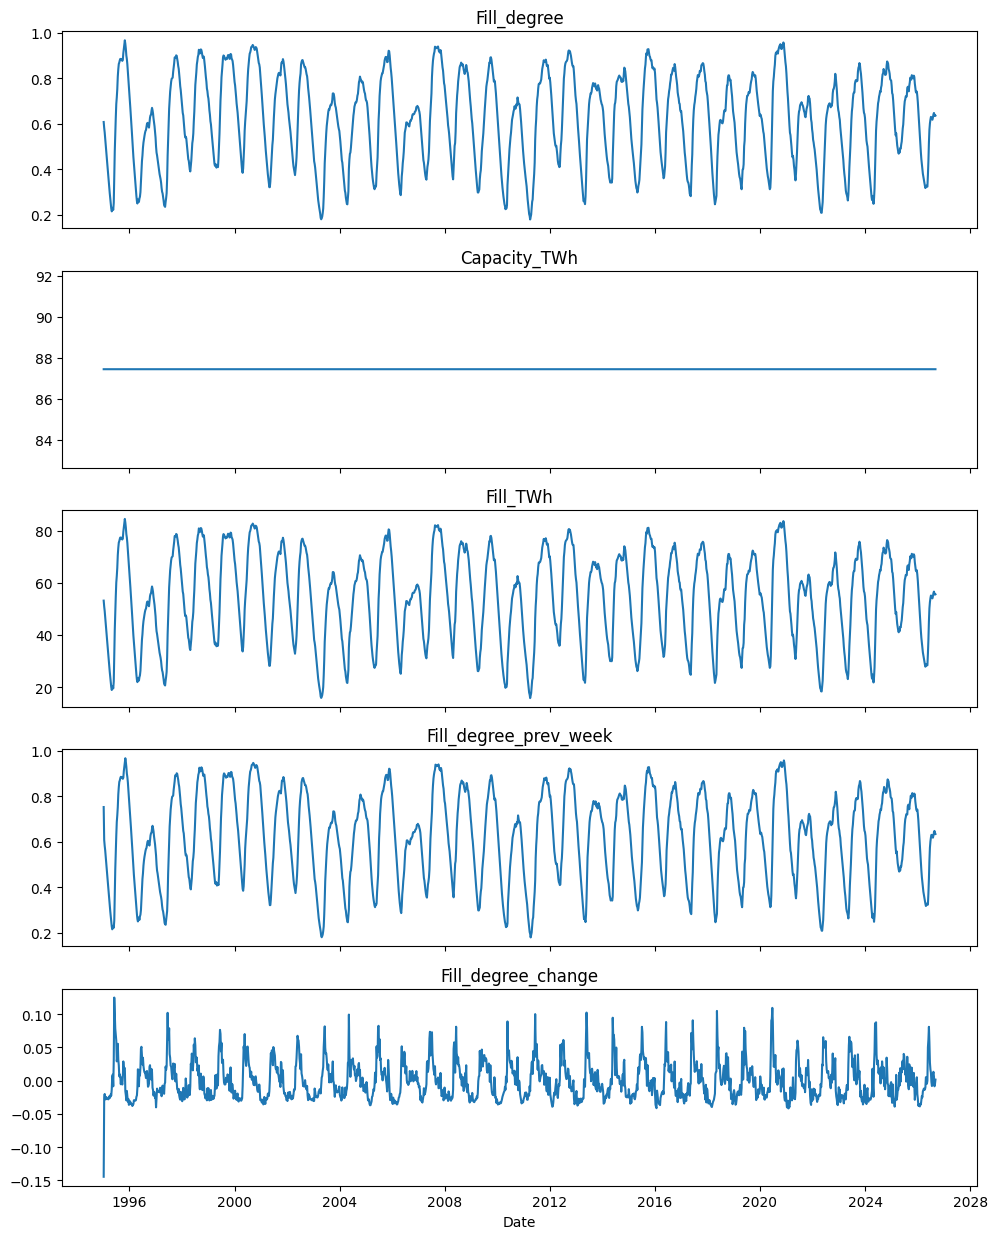

In [4]:
fig, axes = plt.subplots(len(df.columns), 1, figsize=(10, 2.5 * len(df.columns)), sharex=True)

for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col])
    ax.set_title(col)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 5. Plot all columns together

The columns are on very different scales — `Fill_degree` and
`Fill_degree_change` are small fractions (roughly -0.2 to 1.0), while
`Capacity_TWh` and `Fill_TWh` are tens of TWh. Plotting them directly on one
y-axis would flatten the small-scale series to a nearly straight line. To
make the comparison natural, each column is min-max normalized to a 0-1
range before plotting together, and the original units are kept in the
legend for reference.


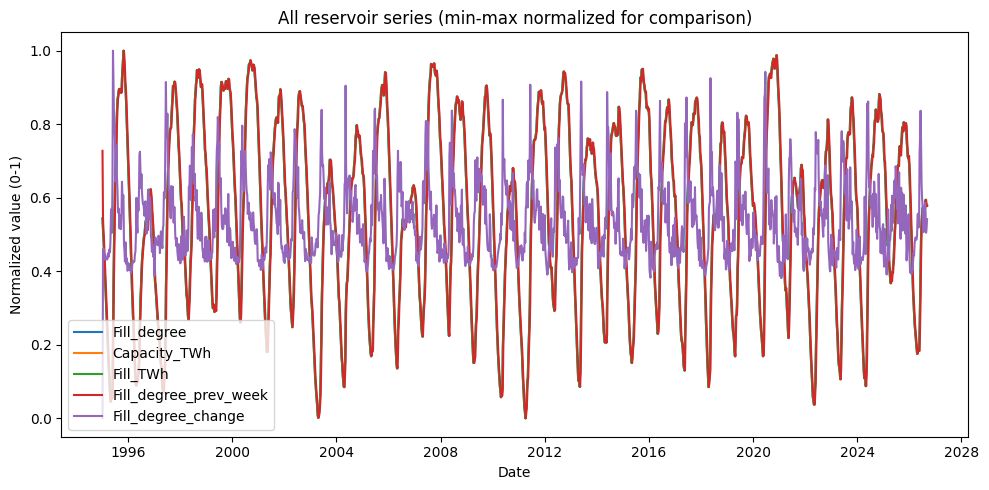

In [5]:
normalized = (df - df.min()) / (df.max() - df.min())

fig, ax = plt.subplots(figsize=(10, 5))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col)

ax.set_title("All reservoir series (min-max normalized for comparison)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized value (0-1)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()
